In [1]:
import os

# 1. Upload the kaggle.json file you just downloaded (Colab only)
try:
    from google.colab import files
    if not os.path.exists("/root/.kaggle/kaggle.json"):
        print("Please upload your kaggle.json file:")
        uploaded = files.upload()
        !mkdir -p ~/.kaggle
        !cp kaggle.json ~/.kaggle/
        !chmod 600 ~/.kaggle/kaggle.json
    # 2. Download the dataset using kaggle CLI
    # Replace 'user/dataset-name' with the string from the Kaggle URL
    !kaggle datasets download -d user/dataset-name
    # 3. Unzip it
    !unzip -q dataset-name.zip -d ./data
except ImportError:
    print("Note: This notebook is designed for Google Colab.")
    print("If running locally, ensure you have set up your Kaggle credentials.")
    print("Download the accident dataset manually or use opendatasets in the next cell.")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
unzip:  cannot find or open dataset-name.zip, dataset-name.zip.zip or dataset-name.zip.ZIP.


In [2]:
import os
!pip install opendatasets
import opendatasets as od
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import json
import math
import numpy as np
import glob
import seaborn as sns
import gzip
import yaml
import os.path as osp
import random
from pathlib import Path
from collections import defaultdict, deque

# Define Kaggle dataset URL
dataset_url = 'https://www.kaggle.com/competitions/accident/data'
path = "./accident/sim_dataset" # Corrected path to point to the downloaded dataset
is_kaggle = True # Flag for Kaggle environment specific path handling

def load_json(path, use_gzip=False):
    """Load JSON file, optionally from gzip compression."""
    if use_gzip:
        with gzip.open(path, 'rt', encoding="utf-8") as f:
            return json.load(f)
    else:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)

def load_yaml(path):
    """Load YAML configuration file."""
    with open(path, 'r') as f:
        return yaml.safe_load(f)

print("Core imports and utility functions loaded successfully")

Core imports and utility functions loaded successfully


In [3]:
od.download(dataset_url)

100%|██████████| 15.6G/15.6G [02:51<00:00, 97.6MB/s]



Extracting archive ./accident/accident.zip to ./accident


In [4]:
annotation_path = glob.glob(f"{path}/video_annotations/*/*.json") # Using f-string with 'path'
anno_files = [os.path.basename(p) for p in annotation_path]
print("Total annotation files:", len(anno_files))

path_videos = f"{path}/videos" # Using f-string with 'path'
videos_folders = os.listdir(path_videos)
l = []
for folder in videos_folders:
    videos_folder_path = os.path.join(path_videos, folder)
    video_files = [f for f in os.listdir(videos_folder_path)]
    l.append(video_files)

flat_list = [item for sublist in l for item in sublist]
print(f"Total videos files: {len(flat_list)}")

Total annotation files: 2211
Total videos files: 2211


In [5]:
csv_r = osp.join(path, 'labels.csv')
df = pd.read_csv(csv_r)

display(df.head(10))
print("\nTotal rows in DataFrame:", len(df))
print("\nFirst row details:")
print(df.iloc[0,])

,rgb_path,annotations_path,type,accident_time,accident_frame,center_x,center_y,x1,y1,x2,y2,map,weather,camera_position,no_frames,duration,height,width,annotations_start_offset
0,videos/sideswipe/Town05_sideswipe_rain_44.mp4,video_annotations/Town05_sideswipe_rain_44.jso...,sideswipe,9.55,191,0.549219,0.387037,0.514583,0.350000,0.583854,0.424074,Town05,rain,44,391,19.55,1080,1920,31
1,videos/sideswipe/Town05_sideswipe_clear_00.mp4,video_annotations/Town05_sideswipe_clear_00.js...,sideswipe,8.65,173,0.494010,0.679167,0.453125,0.595370,0.534896,0.762963,Town05,clear,0,416,20.80,1080,1920,50
2,videos/sideswipe/Town05_sideswipe_sunset_03.mp4,video_annotations/Town05_sideswipe_sunset_03.j...,sideswipe,10.00,200,0.569531,0.890278,0.474479,0.781481,0.664583,0.999074,Town05,sunset,3,407,20.35,1080,1920,40
3,videos/sideswipe/Town05_sideswipe_night_30.mp4,video_annotations/Town05_sideswipe_night_30.js...,sideswipe,7.75,155,0.427604,0.600000,0.393229,0.551852,0.461979,0.648148,Town05,night,30,488,24.40,1080,1920,68
4,videos/sideswipe/Town05_sideswipe_clear_26.mp4,video_annotations/Town05_sideswipe_clear_26.js...,sideswipe,9.40,188,0.579948,0.261111,0.541146,0.195370,0.618750,0.326852,Town05,clear,26,468,23.40,1080,1920,33
5,videos/sideswipe/Town05_sideswipe_night_14.mp4,video_annotations/Town05_sideswipe_night_14.js...,sideswipe,6.60,132,0.409115,0.539352,0.376563,0.457407,0.441667,0.621296,Town05,night,14,566,28.30,1080,1920,96
6,videos/sideswipe/Town05_sideswipe_rain_43.mp4,video_annotations/Town05_sideswipe_rain_43.jso...,sideswipe,8.75,175,0.622917,0.441204,0.576042,0.402778,0.669792,0.479630,Town05,rain,43,277,13.85,1080,1920,54
7,videos/sideswipe/Town05_sideswipe_clear_19.mp4,video_annotations/Town05_sideswipe_clear_19.js...,sideswipe,9.55,191,0.473177,0.613426,0.397917,0.549074,0.548438,0.677778,Town05,clear,19,361,18.05,1080,1920,31
8,videos/sideswipe/Town05_sideswipe_clear_17.mp4,video_annotations/Town05_sideswipe_clear_17.js...,sideswipe,7.20,144,0.364063,0.848611,0.320312,0.751852,0.407813,0.945370,Town05,clear,17,374,18.70,1080,1920,95
9,videos/sideswipe/Town05_sideswipe_sunset_11.mp4,video_annotations/Town05_sideswipe_sunset_11.j...,sideswipe,6.90,138,0.598958,0.668519,0.560937,0.600926,0.636979,0.736111,Town05,sunset,11,405,20.25,1080,1920,87



Total rows in DataFrame: 2211

First row details:
rgb_path                        videos/sideswipe/Town05_sideswipe_rain_44.mp4
annotations_path            video_annotations/Town05_sideswipe_rain_44.jso...
type                                                                sideswipe
accident_time                                                            9.55
accident_frame                                                            191
center_x                                                             0.549219
center_y                                                             0.387037
x1                                                                   0.514583
y1                                                                       0.35
x2                                                                   0.583854
y2                                                                   0.424074
map                                                                    Town05
weather      

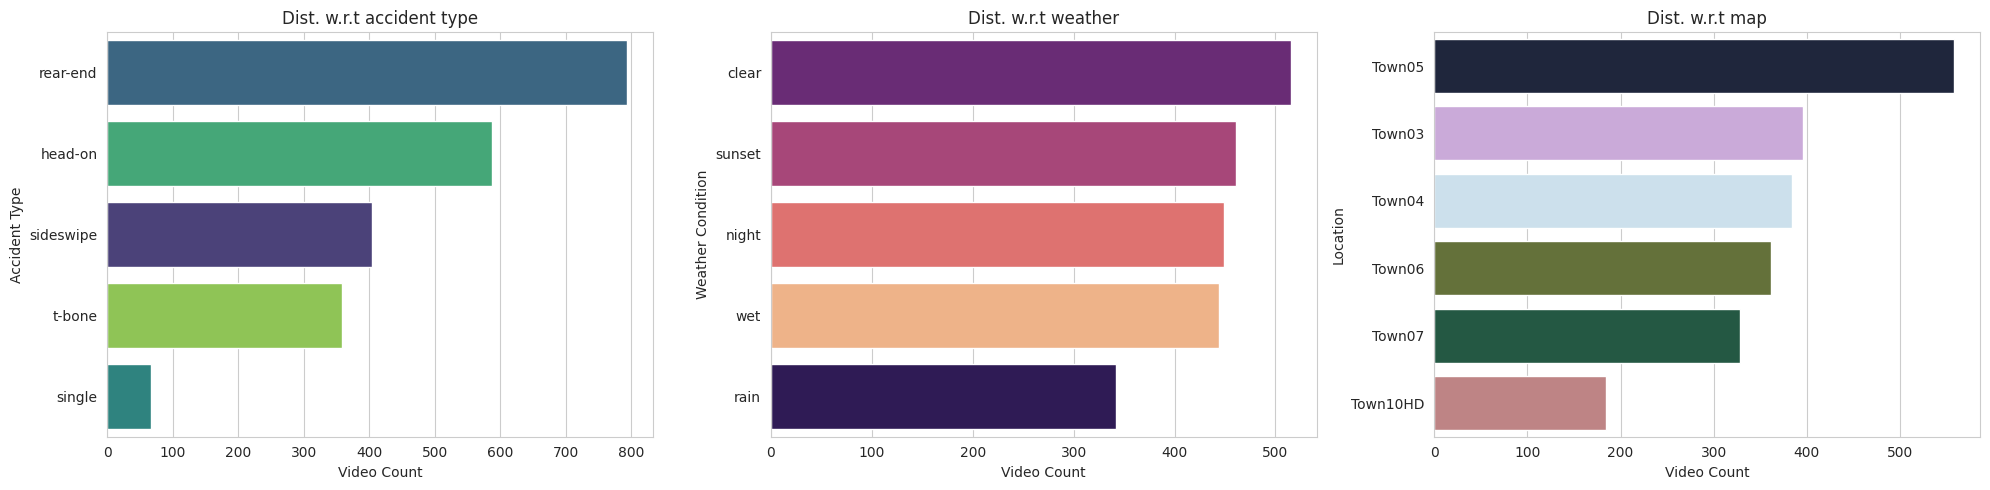

In [6]:
sns.set_style('whitegrid')

fig, axes = plt.subplots(1, 3, figsize = (20, 5))

sns.countplot(
    y = "type",
    hue = "type",
    data = df,
    ax=axes[0],
    order = df["type"].value_counts().index,
    palette = 'viridis',
    legend = False
)
axes[0].set_title("Dist. w.r.t accident type")
axes[0].set_xlabel("Video Count")
axes[0].set_ylabel("Accident Type")

sns.countplot(
    y = "weather",
    hue = "weather",
    data = df,
    ax=axes[1],
    order = df["weather"].value_counts().index,
    palette = 'magma',
    legend = False
)
axes[1].set_title("Dist. w.r.t weather")
axes[1].set_xlabel("Video Count")
axes[1].set_ylabel("Weather Condition")

sns.countplot(
    y = "map",
    hue = "map",
    data = df,
    ax = axes[2],
    order = df["map"].value_counts().index,
    palette = 'cubehelix',
    legend = False
)

axes[2].set_title("Dist. w.r.t map")
axes[2].set_xlabel("Video Count")
axes[2].set_ylabel("Location")

plt.tight_layout()
plt.show()

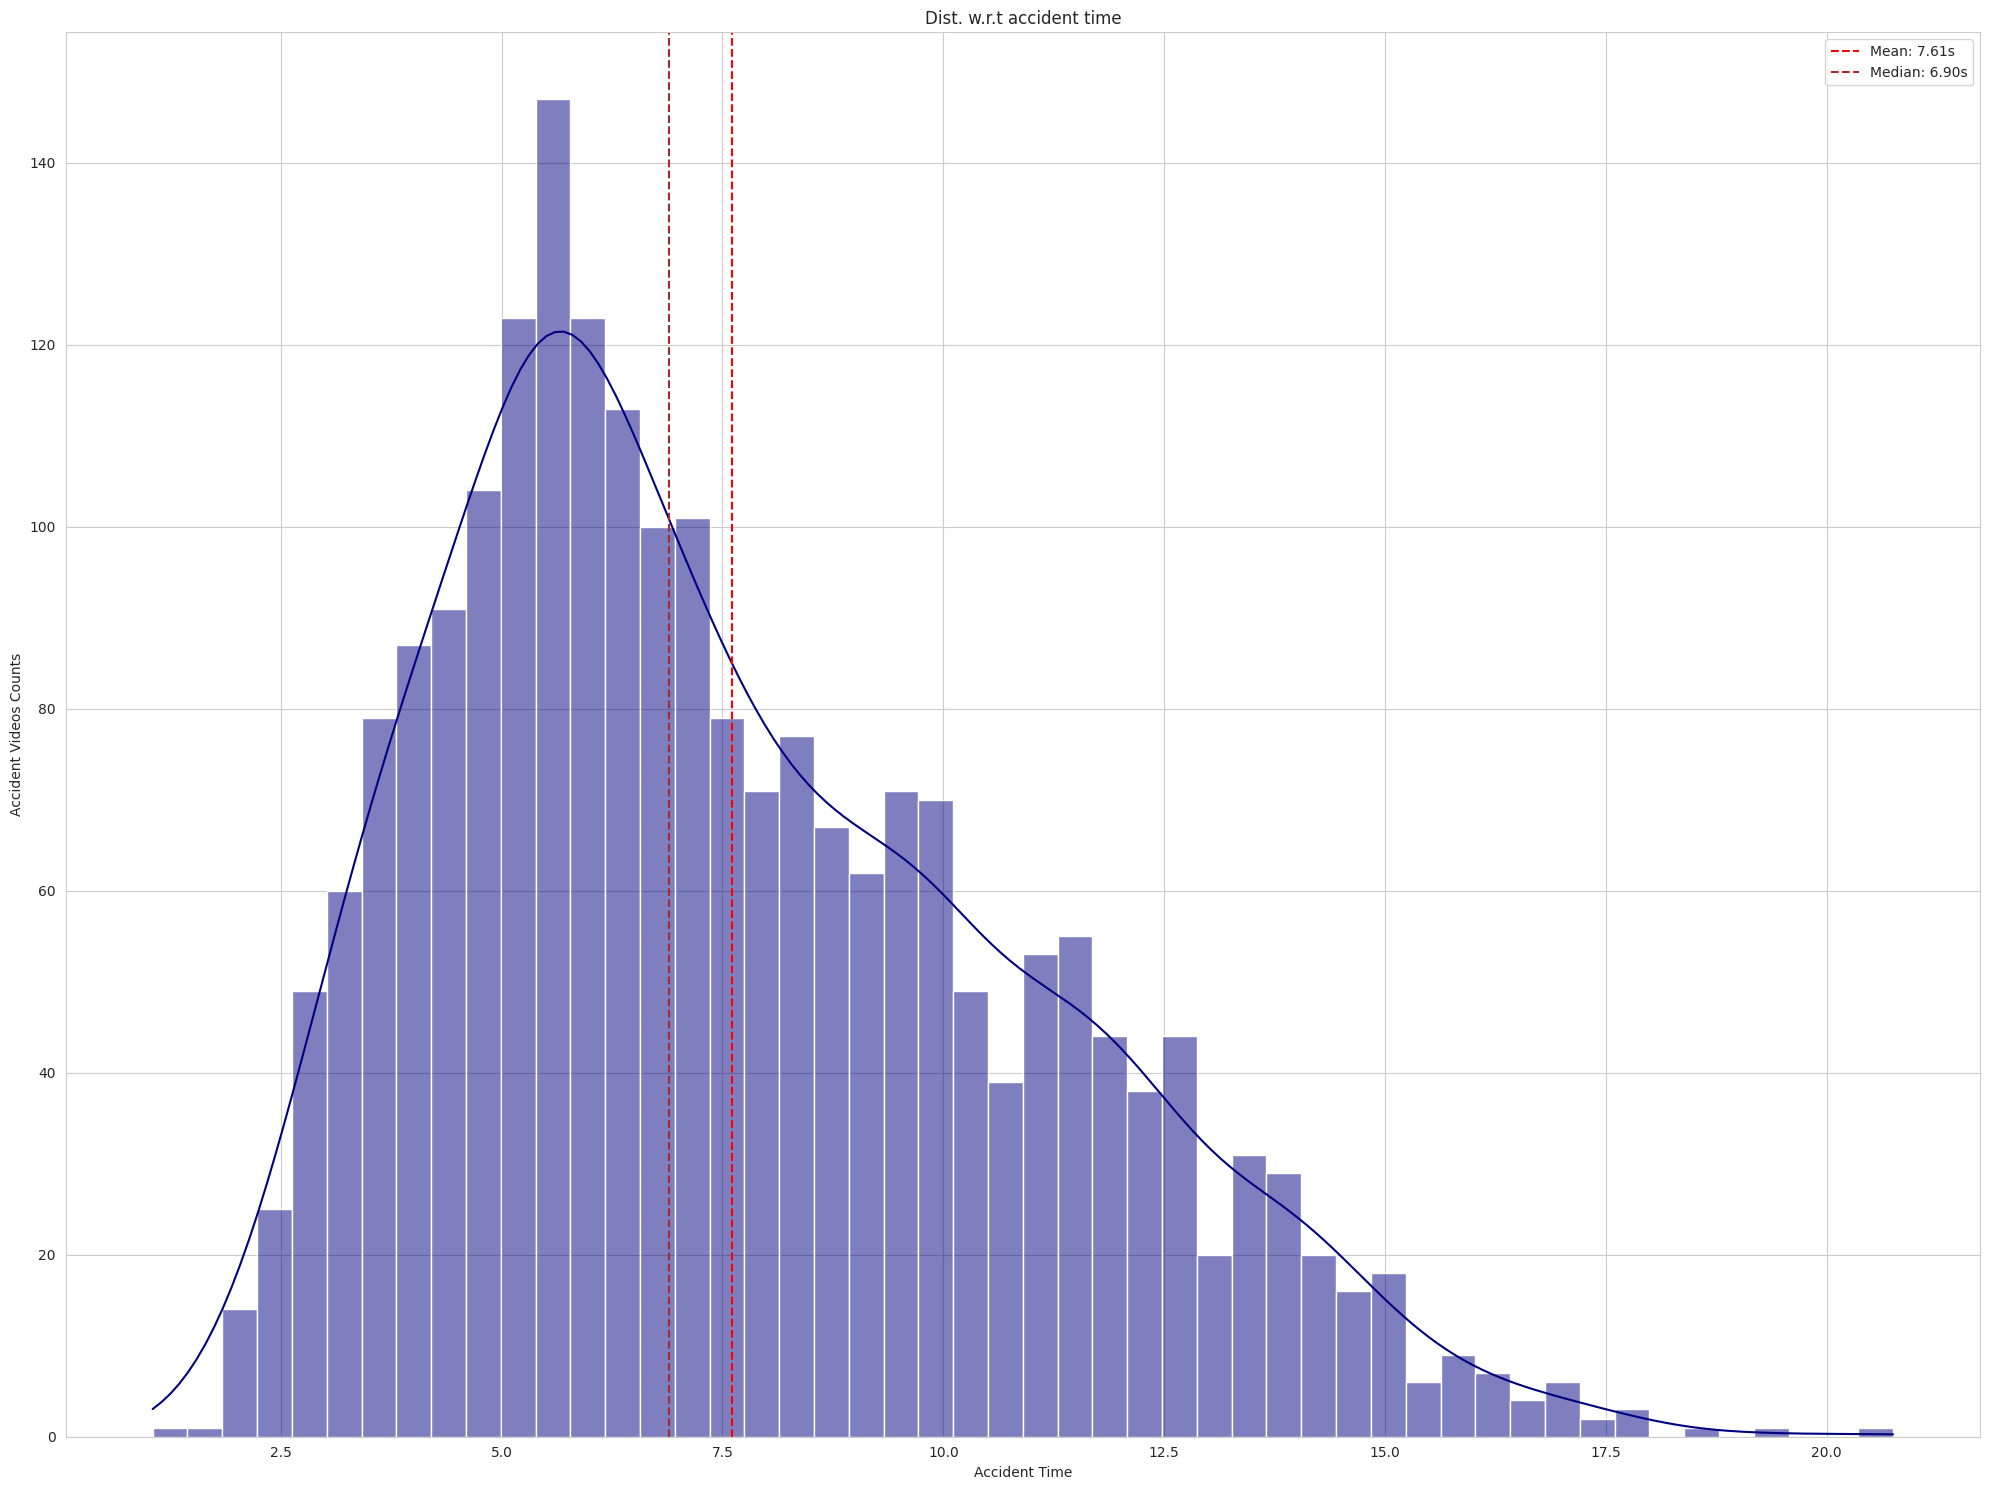

In [7]:
fig, axes = plt.subplots(1, 1, figsize = (20, 15))

sns.histplot(
    data = df,
    x = "accident_time",
    bins = 50,
    kde = True,
    color = "navy"
)

axes.set_title("Dist. w.r.t accident time")
axes.set_xlabel("Accident Time")
axes.set_ylabel("Accident Videos Counts")

mean_time = df['accident_time'].mean()
plt.axvline(mean_time, color = 'red', linestyle = "--", label = f"Mean: {mean_time:.2f}s")
median_time = df['accident_time'].median()
plt.axvline(median_time, color = 'brown', linestyle = "--", label = f"Median: {median_time:.2f}s")

axes.legend()
plt.tight_layout()
plt.show()

In [8]:
yaml_path = osp.join(path, "annotation_classes.yaml")
cls_mapping = load_yaml(yaml_path)

# This is a dictionary like: {14: "Car", 15: "Truck", 18: "Motorcycle", ...}
tag_to_cls_mapping = cls_mapping["names"]

print("Tag to class mapping:")
print(tag_to_cls_mapping)

Tag to class mapping:
{0: 'Unlabeled', 1: 'Roads', 2: 'SideWalks', 3: 'Building', 4: 'Wall', 5: 'Fence', 6: 'Pole', 7: 'TrafficLight', 8: 'TrafficSign', 9: 'Vegetation', 10: 'Terrain', 11: 'Sky', 12: 'Pedestrian', 13: 'Rider', 14: 'Car', 15: 'Truck', 16: 'Bus', 17: 'Train', 18: 'Motorcycle', 19: 'Bicycle', 20: 'Static', 21: 'Dynamic', 22: 'Other', 29: 'Van'}


Video frames: 416
Last annotated frame: 471
Successfully loaded frame: 415


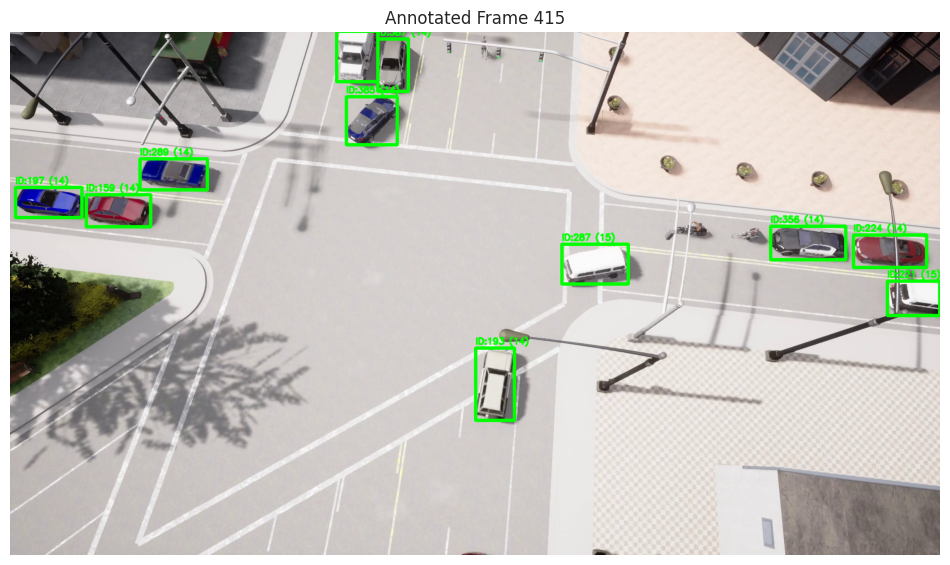

In [9]:
video_path_specific = f"{path}/videos/head-on/Town03_head-on_clear_03.mp4" # Using f-string with 'path'
anno_path_specific  = f"{path}/video_annotations/Town03_head-on_clear_03.json/Town03_head-on_clear_03.json" # Using f-string with 'path'

# ---------------- LOAD ANNOTATIONS ----------------
with open(anno_path_specific, 'r') as anf:
    data_specific = json.load(anf)

# Map: frame_number -> objects
anno_map_specific = {obj['iteration']: obj['objects'] for obj in data_specific['base']}

# VERY IMPORTANT: never trust order in JSON
last_frame_id_specific = max(anno_map_specific.keys())
obj_in_frame_specific = anno_map_specific[last_frame_id_specific]


# ---------------- OPEN VIDEO ----------------
cap_specific = cv2.VideoCapture(video_path_specific)

if not cap_specific.isOpened():
    raise RuntimeError("Video could not be opened")

total_frames_specific = int(cap_specific.get(cv2.CAP_PROP_FRAME_COUNT))
print("Video frames:", total_frames_specific)
print("Last annotated frame:", last_frame_id_specific)

# Prevent out-of-range frame access
safe_frame_specific = min(last_frame_id_specific, total_frames_specific - 1)

# Move video pointer
cap_specific.set(cv2.CAP_PROP_POS_FRAMES, safe_frame_specific)

# READ FRAME
ret, frame_specific = cap_specific.read()

if not ret or frame_specific is None:
    raise RuntimeError(f"Failed to read frame {safe_frame_specific}")

print("Successfully loaded frame:", safe_frame_specific)


# ---------------- DRAW BOUNDING BOXES ----------------
for f_obj in obj_in_frame_specific:

    # bbox format: [(x1,y1),(x2,y2)]
    (x1, y1), (x2, y2) = f_obj['2d_bbox']

    # ignore tiny detections (dataset noise)
    w, h = abs(x2 - x1), abs(y2 - y1)
    if w < 40 or h < 40:
        continue

    # convert to int
    x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])

    # draw rectangle
    cv2.rectangle(frame_specific, (x1, y1), (x2, y2), (0, 255, 0), 5)

    # label
    label = f"ID:{f_obj['id']} ({f_obj['tag']})"
    cv2.putText(frame_specific, label, (x1, y1 - 8),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6, (0, 255, 0), 2, cv2.LINE_AA)


cap_specific.release()


# ---------------- DISPLAY ----------------
frame_rgb_specific = cv2.cvtColor(frame_specific, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,7))
plt.imshow(frame_rgb_specific)
plt.title(f"Annotated Frame {safe_frame_specific}")
plt.axis("off")
plt.show()

In [10]:
# Select a random sample for video processing
sample_index_vid = random.randint(0, len(df) - 1)
sample_row_vid = df.iloc[sample_index_vid]

video_path = osp.join(path, sample_row_vid['rgb_path'])
print(f"Processing video: {video_path}")

if is_kaggle:
    annotations_path = osp.join(path, sample_row_vid["annotations_path"])
    if annotations_path.endswith(".gz"):
        annotations_path = annotations_path.removesuffix(".gz")
    # The format of annotations_path in labels.csv is like:
    # 'video_annotations/Town05_sideswipe_rain_44.json.gz'
    # osp.basename(annotations_path) would give 'Town05_sideswipe_rain_44.json.gz'
    # After .removesuffix(".gz"), it becomes 'Town05_sideswipe_rain_44.json'
    # So the correct path structure should be 'path/video_annotations/Town05_sideswipe_rain_44.json/Town05_sideswipe_rain_44.json'
    # The current `osp.join(annotations_path, osp.basename(annotations_path))` is problematic.
    # Let's reconstruct it.
    anno_filename = Path(sample_row_vid["annotations_path"]).stem # Gets 'Town05_sideswipe_rain_44.json'
    annotations_path = osp.join(path, "video_annotations", anno_filename, anno_filename)
else:
    annotations_path = osp.join(path, sample_row_vid["annotation_path"])

print(f"Using annotations from: {annotations_path}")
annotations = load_json(annotations_path, use_gzip=not is_kaggle)

# Extract relevant annotation sections
base_annotations      = annotations["base"]      # Per-frame car detections (where are the cars?)
# collision_annotations = annotations["collision"] # Which frames show a collision? (Not directly used, inferred from bbox overlap)
# sensor_annotations     = annotations["sensor"]    # Where is the camera?

annotations_offset = sample_row_vid["annotations_start_offset"]

# Build frame_detections map
frame_detections = {}
for item in base_annotations:
    it = int(item["iteration"])
    frame_detections[it] = item["objects"]

# Sorted iterations (THIS IS CRITICAL)
sorted_iterations = sorted(frame_detections.keys())

print("Total annotated iterations:", len(sorted_iterations))
print("First 5 iterations:", sorted_iterations[:5])

Processing video: ./accident/sim_dataset/videos/head-on/Town03_head-on_sunset_17.mp4
Using annotations from: ./accident/sim_dataset/video_annotations/Town03_head-on_sunset_17.json/Town03_head-on_sunset_17.json
Total annotated iterations: 395
First 5 iterations: [49, 50, 51, 52, 53]


In [11]:
def boxes_overlap(b1, b2):
    (x1, y1), (x2, y2) = b1
    (x3, y3), (x4, y4) = b2

    return not (x2 < x3 or x4 < x1 or y2 < y3 or y4 < y1)

collision_data = {}

for frame in base_annotations:
    it = int(frame["iteration"])
    objects = frame["objects"]

    for i in range(len(objects)):
        for j in range(i + 1, len(objects)):

            b1 = objects[i]["2d_bbox"]
            b2 = objects[j]["2d_bbox"]

            if boxes_overlap(b1, b2):

                x1 = min(b1[0][0], b2[0][0])
                y1 = min(b1[0][1], b2[0][1])
                x2 = max(b1[1][0], b2[1][0])
                y2 = max(b1[1][1], b2[1][1])

                collision_data[it] = {
                    "collision_bbox": [[x1, y1], [x2, y2]]
                }
                break # Only need one collision per frame for the indicator

print("Collision frames detected:", len(collision_data))

Collision frames detected: 395


In [12]:
def get_bbox_center(bbox):
    (x1, y1), (x2, y2) = bbox
    return int((x1 + x2) / 2), int((y1 + y2) / 2)

def draw_tracks_on_video(
    video_path,
    frame_detections,
    collision_data,
    output_path,
    tag_to_cls_mapping,
    sorted_iterations
):

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("Error opening video")
        return

    fps    = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    writer = cv2.VideoWriter(
        output_path,
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (width, height)
    )

    track_history = defaultdict(lambda: deque(maxlen=25))
    alert_radius_base = 18

    # ITERATION-BASED SYNC
    iter_idx = 0
    total_iters = len(sorted_iterations)

    while True:
        ret, frame = cap.read()
        if not ret or iter_idx >= total_iters:
            break

        iteration = sorted_iterations[iter_idx]

        # ---------------- COLLISION (BACKGROUND) ----------------
        if iteration in collision_data:
            bbox = collision_data[iteration]["collision_bbox"]

            # Draw collision box
            (x1, y1), (x2, y2) = bbox
            cv2.rectangle(
                frame,
                (int(x1), int(y1)),
                (int(x2), int(y2)),
                (255, 0, 255),
                2
            )

            # Impact center
            cx, cy = get_bbox_center(bbox)

            # Pulsing alert circle
            pulse = alert_radius_base + (iter_idx % 6) * 2
            cv2.circle(
                frame,
                (cx, cy),
                pulse,
                (0, 0, 255),
                thickness=3
            )

            # Flashing alert text
            if iter_idx % 2 == 0:
                cv2.putText(
                    frame,
                    "⚠ COLLISION ⚠",
                    (max(0, cx - 80), max(40, cy - 30)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.9,
                    (0, 0, 255),
                    3,
                    cv2.LINE_AA
                )

        # ---------------- OBJECTS ----------------
        if iteration in frame_detections:
            for car in frame_detections[iteration]:
                # Ensure 2d_bbox exists before trying to access it
                if "2d_bbox" not in car or len(car["2d_bbox"]) != 2:
                    continue

                (x1, y1), (x2, y2) = car["2d_bbox"]

                # Filter out tiny or invalid bounding boxes
                w, h = abs(x2 - x1), abs(y2 - y1)
                if w < 40 or h < 40: # Use a reasonable threshold for objects of interest
                    continue

                x1, y1, x2, y2 = map(int, (x1, y1, x2, y2))

                cx = (x1 + x2) // 2
                cy = (y1 + y2) // 2
                track_history[car["id"]].append((cx, cy))

                cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 2)

                tag = car["tag"]
                label = tag_to_cls_mapping.get(tag, "Unknown") # Use the loaded mapping
                cv2.putText(
                    frame,
                    f"{label}:{car['id']}",
                    (x1, max(0, y1 - 8)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (255, 255, 255),
                    1
                )

        # ---------------- TRAILS ----------------
        for pts in track_history.values():
            for i in range(1, len(pts)):
                trail_color = (0, 0, 255)  # normal red
                if iteration in collision_data:
                    trail_color = (0, 255, 255)  # yellow after impact

                cv2.line(frame, pts[i - 1], pts[i], trail_color, 2)

        writer.write(frame)
        iter_idx += 1

    cap.release()
    writer.release()
    print("Saved:", output_path)

In [13]:
annotated_video_path = "annotated_output.mp4" # Renamed output for clarity

draw_tracks_on_video(
    video_path=video_path,
    frame_detections=frame_detections,
    collision_data=collision_data,
    sorted_iterations=sorted_iterations,
    output_path=annotated_video_path,
    tag_to_cls_mapping=tag_to_cls_mapping,
)

Saved: annotated_output.mp4


In [14]:
# Install required packages if needed (uncomment if needed)
!pip install ruptures ultralytics tqdm lap

# Additional imports for YOLO tracking and change point detection
from tqdm import tqdm
import ruptures as rpt
from itertools import combinations
from typing import cast, Generator

import torch
from ultralytics import YOLO

print("YOLO and additional imports loaded successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 97.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO and additional imports loaded successfully


In [15]:
# Define paths and load video files
DETECTIONS_PATH = Path("./inference-yolo11x")
DETECTIONS_PATH.mkdir(parents=True, exist_ok=True)
DATASET_PATH = Path("./accident") # Corrected path based on previous download

# Assuming videos are in DATASET_PATH / 'sim_dataset' / 'videos'
video_paths = list((DATASET_PATH / "sim_dataset" / "videos").rglob("*.mp4"))
metadata_df = pd.read_csv(DATASET_PATH/"test_metadata.csv", index_col="path")

# Limit the number of videos processed for testing purposes
take = 5 # comment out this line to run on all
video_paths = video_paths[:(take or len(video_paths))]

print(f"Processing {len(video_paths)} videos.")


Processing 5 videos.


In [16]:
# Algorithm parameters:
YOLO_MODEL_PATH="./yolo11x.pt" # Used pre-trained YOLO model.
YOLO_IMAGE_RESOLUTION=1280  # Input image resolution for YOLO (must be multiple of 32). Higher = more accurate but slower
YOLO_BATCH_SIZE=8  # Number of frames processed simultaneously. Increase for faster processing if GPU memory allows
CONFIDENCE_THRESHOLD = 0.15  # Minimum confidence score for object detection (0-1). Lower = more detections but more false positives
CUDA_DEVICE_ID = 0  # GPU device ID to use (0 for first GPU). Set to None or use CPU if no GPU available


In [17]:
class Tracker:
    def __init__(self, batch_size: int = YOLO_BATCH_SIZE):
        self.batch_size = batch_size

        self.model = YOLO(YOLO_MODEL_PATH)
        device = torch.device(f"cuda:{CUDA_DEVICE_ID}" if torch.cuda.is_available() and CUDA_DEVICE_ID is not None else "cpu")
        self.model.to(device)
        print(f"Using YOLO model: {YOLO_MODEL_PATH} at {device.type} device.")

    def track(
            self, batches: Generator[list[cv2.typing.MatLike], None, None]
    ) -> dict:
        """Inference on images.

        Args:
            batches: Iterable of batched images.
        Returns:
            List of processed predictions.
        """
        bboxes = []
        frames_indices = []
        class_ids, track_ids, confidences = [], [], []
        try:
            for batch_index, batch in enumerate(batches):
                results = self.model.track(
                    batch,
                    imgsz=YOLO_IMAGE_RESOLUTION,  # must be a multiple of stride 32
                    verbose=False,
                    tracker="bytetrack.yaml",
                    persist=True,
                    conf=CONFIDENCE_THRESHOLD,
                )

                for i, x in enumerate(results):
                    if x.boxes is not None and x.boxes.is_track:
                        frames_indices.append(batch_index * self.batch_size + i)
                        bboxes.append(x.boxes.xyxy.cpu().numpy().tolist())
                        class_ids.append(x.boxes.cls.cpu().numpy().astype(int).tolist())
                        track_ids.append(x.boxes.id.cpu().numpy().tolist())
                        confidences.append(x.boxes.conf.cpu().numpy().tolist())
        except Exception as e:
            print(f"ERROR: {e}")
        finally:
            assert (
                hasattr(self.model, "predictor")
                and self.model.predictor is not None
                and hasattr(self.model.predictor, "trackers")
                and self.model.predictor.trackers is not None
            )

            for tracker in self.model.predictor.trackers:
                tracker.reset()

        return {
            "frames": frames_indices,
            "bboxes": bboxes,
            "class_ids": class_ids,
            "track_ids": track_ids,
            "confidences": confidences,
        }

    def load_batched(self, cap: cv2.VideoCapture):
        """Load video frames in batches.

        Args:
            cap: Opened cv2.VideoCapture object.
        Yields:
            Batches of video frames.
        """
        while True:
            batch: list[cv2.typing.MatLike] = []
            for _ in range(self.batch_size):
                ret, frame = cap.read()
                if not ret:
                    return
                batch.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            yield batch

    def process_video_file(self, video_path: Path) -> dict:
        """Track objects in a video file.

        Args:
            video_path: Path to a video file.
        Returns:
            Dict with list of detections and other relevant dat
        """
        cap = None
        try:
            cap = cv2.VideoCapture(str(video_path)) # Convert Path to string for cv2.VideoCapture

            detections = self.track(self.load_batched(cap))
            detections = {
                **detections,
                "path": str(video_path.relative_to(DATASET_PATH).as_posix())
            }
        finally:
            if cap:
                cap.release()

        return detections


In [18]:
tracker = Tracker()
all_detections = []

for video_path in tqdm(video_paths, desc="Processing videos"):
    detections = tracker.process_video_file(video_path)
    all_detections.append(detections)

    # Save detections to a JSON file
    output_filename = DETECTIONS_PATH / video_path.with_suffix(".json").name
    with open(output_filename, "w") as f:
        json.dump(detections, f)

print("Video processing complete and detections saved to files.")
# You can now further process `all_detections`


Using YOLO model: ./yolo11x.pt at cuda device.


Processing videos: 100%|██████████| 5/5 [05:14<00:00, 62.85s/it]

Video processing complete and detections saved to files.


In [19]:
def find_bbox_size_change(detections: dict) -> tuple[int, np.ndarray]:
    """
    Find biggest change in bbox sizes in video.

    Returns:
        int: A frame with biggest change in bbox sizes
    """
    bbox_sizes = []
    for bboxes in detections["bboxes"]:
        if len(bboxes) == 0:
            if len(bbox_sizes) > 0:
                # If no bboxes detected in current frame, use the last known bbox size (assuming objects are still present but not detected)
                bbox_sizes.append(bbox_sizes[-1])
            else:
                # No bboxes detected (yet), default to 0
                bbox_sizes.append(0)
        else:
            bbox_pixel_size = sum([abs(x2 - x1) * abs(y2 - y1) for x1, y1, x2, y2 in bboxes])
            bbox_sizes.append(bbox_pixel_size)

    if np.sum(bbox_sizes) == 0:
        # No bboxes detected in video, return the middle frame
        return len(detections["frames"])//2, np.array(bbox_sizes)
    bbox_sizes = np.array(bbox_sizes)
    bbox_sizes = bbox_sizes / np.sum(bbox_sizes)

    changes = rpt.KernelCPD(kernel="rbf").fit_predict(bbox_sizes, n_bkps=1)
    assert changes and len(changes) >= 1
    return ((detections["frames"][changes[0]] + detections["frames"][changes[0]+1]) / 2), bbox_sizes


In [20]:
results: dict[Path, dict] = {}
for video in tqdm(video_paths):
    video = cast(Path, video)
    with open(DETECTIONS_PATH / video.with_suffix(".json").name, "r") as f:
        info = json.load(f)

    # Corrected: Make relative_video_path_str match the format in df['rgb_path']
    # df['rgb_path'] entries are relative to the 'sim_dataset' directory within DATASET_PATH
    relative_video_path_str = str(video.relative_to(DATASET_PATH / "sim_dataset").as_posix())

    # Filter df to find the matching row
    matching_row = df[df['rgb_path'] == relative_video_path_str]

    if not matching_row.empty:
        metadata_row = matching_row.iloc[0]
        fps = metadata_row["no_frames"] / metadata_row["duration"]

        # Find frame with biggest change in bbox sizes
        frame, _ = find_bbox_size_change(info)
        results[info["path"]] = {"frame": frame, "accident_time": frame / fps}
    else:
        print(f"Warning: Metadata not found for video: {relative_video_path_str}")

display(results)


100%|██████████| 5/5 [00:00<00:00, 71.58it/s]


{'sim_dataset/videos/single/Town10HD_single_rain_21.mp4': {'frame': 173.5,
  'accident_time': np.float64(8.675)},
 'sim_dataset/videos/single/Town10HD_single_wet_13.mp4': {'frame': 87.5,
  'accident_time': np.float64(4.375)},
 'sim_dataset/videos/single/Town10HD_single_night_23.mp4': {'frame': 193.5,
  'accident_time': np.float64(9.675)},
 'sim_dataset/videos/single/Town10HD_single_wet_32.mp4': {'frame': 149.5,
  'accident_time': np.float64(7.475)},
 'sim_dataset/videos/single/Town10HD_single_clear_18.mp4': {'frame': 100.5,
  'accident_time': np.float64(5.025)}}

In [21]:
# Assuming all_detections is a list of dictionaries, each representing detections for a video.
# We'll process each video's detections.

# Example for the first video in all_detections:
if all_detections:
    first_video_detections = all_detections[0] # You can iterate through all_detections if needed
    change_frame_index, bbox_sizes_array = find_bbox_size_change(first_video_detections)
    print(f"Frame with biggest change in bbox size: {change_frame_index}")
    print(f"Bbox sizes array (first 10 elements): {bbox_sizes_array[:10]}")
    print(f"Bbox sizes array (last 10 elements): {bbox_sizes_array[-10:]}")
else:
    print("No detections found to process.")


Frame with biggest change in bbox size: 173.5
Bbox sizes array (first 10 elements): [  0.0012289   0.0012193   0.0012294   0.0015994  0.00055977    0.001271   0.0018679   0.0011549  0.00058178   0.0013644]
Bbox sizes array (last 10 elements): [  0.0043065   0.0042949   0.0038822    0.003196   0.0031804   0.0032024   0.0026051   0.0034134   0.0046502   0.0046796]


In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_video_card(
    video_path,
    values_per_frame,
    fps,
    accident_time,
    center_x=None,
    center_y=None,
    title=None,
):
    # ---- Load accident frame ----
    cap = cv2.VideoCapture(str(video_path)) # Convert Path to string
    frame_idx = int(accident_time * fps)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)

    ret, frame = cap.read()
    cap.release()

    if not ret:
        raise RuntimeError(f"Could not read frame from {video_path}")

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Optional: draw accident location
    if center_x is not None and center_y is not None:
        h, w, _ = frame.shape
        px = int(center_x * w)
        py = int(center_y * h)
        cv2.circle(frame, (px, py), 10, (255, 0, 0), -1)

    # ---- Prepare signal plot ----
    time = np.arange(len(values_per_frame)) / fps

    # ---- Build card ----
    fig, (ax_img, ax_plot) = plt.subplots(
        1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1, 1.3]}
    )

    # Image panel
    ax_img.imshow(frame)
    ax_img.set_title(f"Predicted accident at {accident_time:.2f}s")
    ax_img.axis("off")

    # Signal panel
    ax_plot.plot(time, values_per_frame)
    ax_plot.axvline(accident_time, color='r', linestyle='--', label=f'Accident Time: {accident_time:.2f}s')
    ax_plot.set_xlabel("Time (seconds)")
    ax_plot.set_ylabel("Bounding boxes size (normalized)")
    ax_plot.set_title("Bounding box size dynamics")
    ax_plot.legend()

    if title:
        fig.suptitle(title)

    plt.tight_layout()
    plt.show()

print("show_video_card function defined successfully")

show_video_card function defined successfully


In [24]:
for result in results.values():
    result["type"] = "single"

In [25]:
results_df = pd.DataFrame([{"path": str(path), **i, "frame": None } for path, i in results.items()]).drop(columns=["frame"])
results_df.to_csv("submission.csv", index=False)
display(results_df)

,path,accident_time,type
0,sim_dataset/videos/single/Town10HD_single_rain...,8.675,single
1,sim_dataset/videos/single/Town10HD_single_wet_...,4.375,single
2,sim_dataset/videos/single/Town10HD_single_nigh...,9.675,single
3,sim_dataset/videos/single/Town10HD_single_wet_...,7.475,single
4,sim_dataset/videos/single/Town10HD_single_clea...,5.025,single


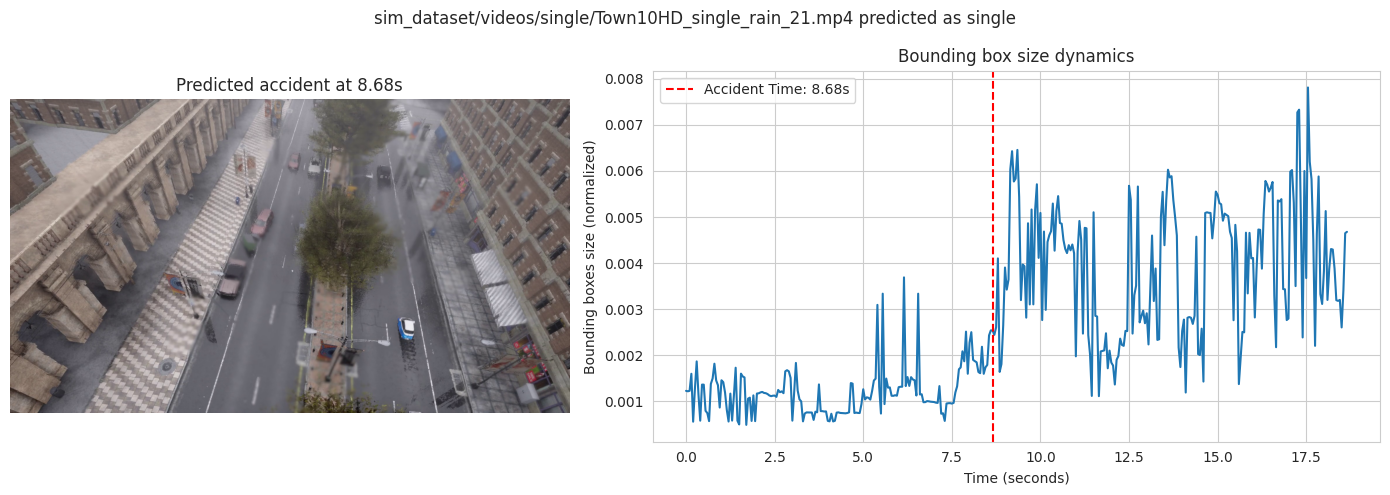

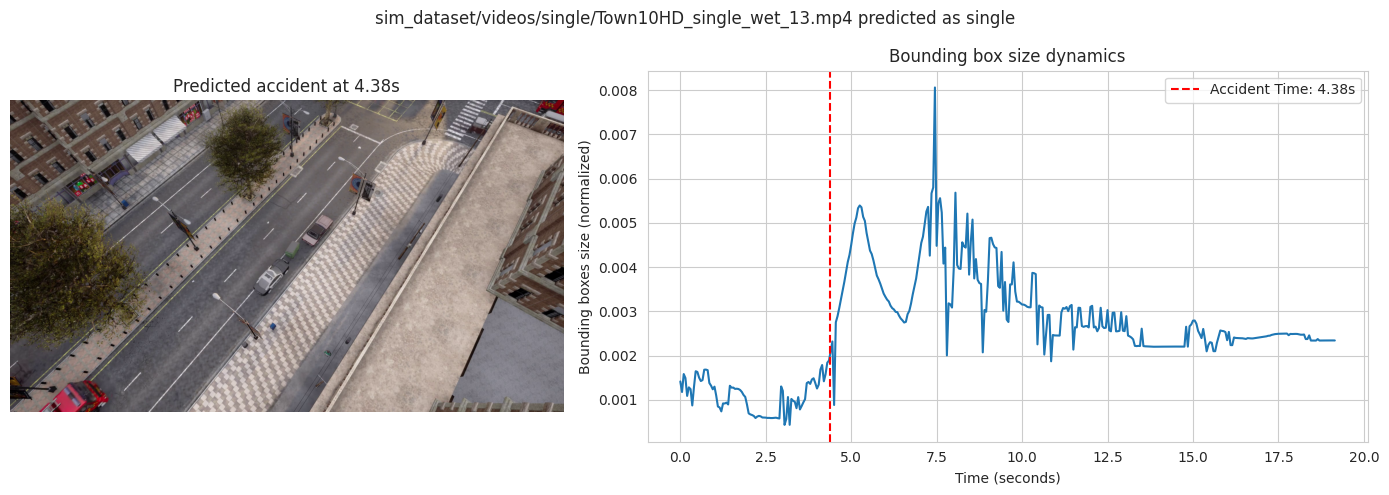

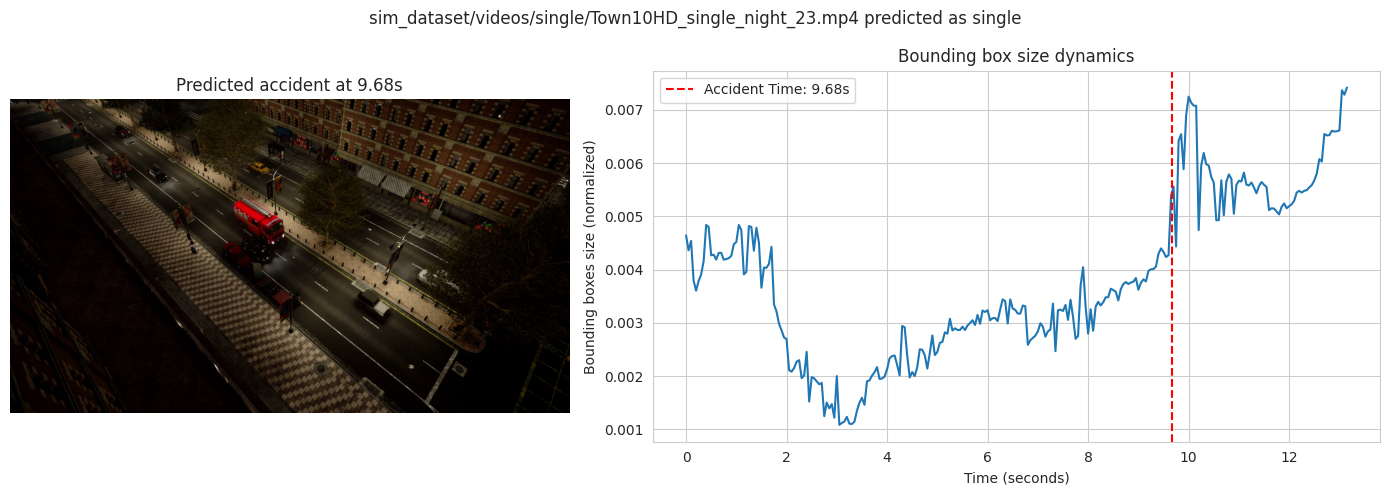

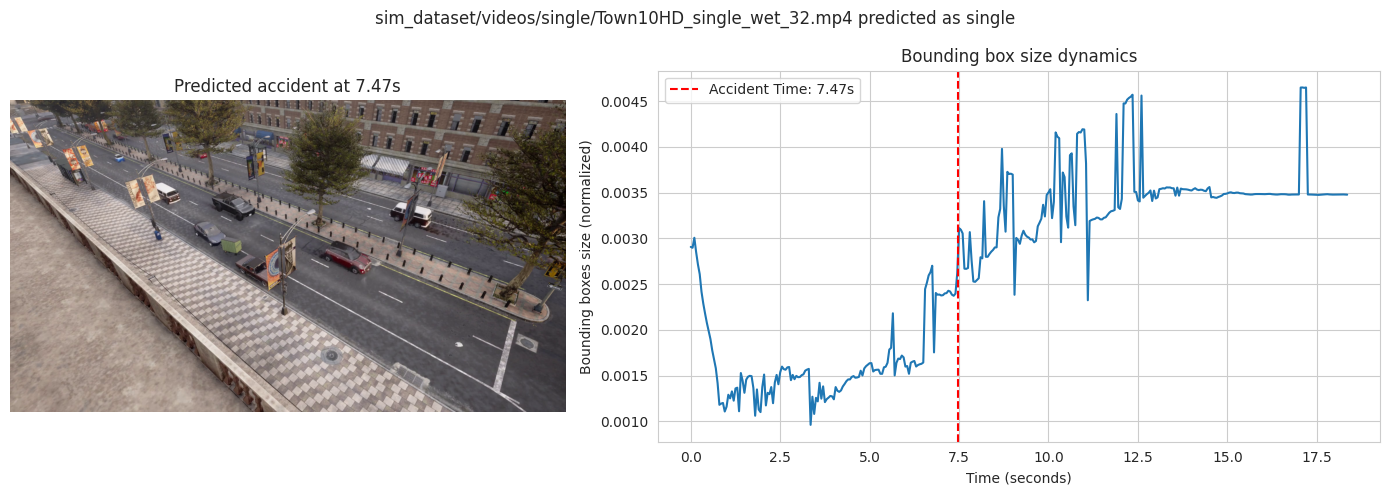

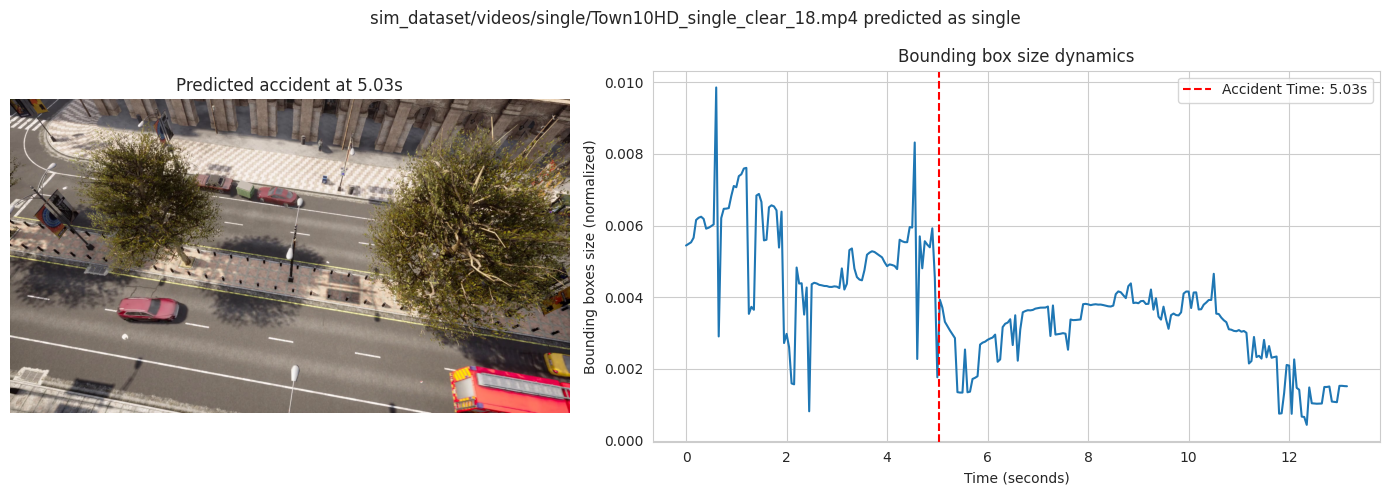

In [26]:
# Visualize results with show_video_card function
# This will display the accident frames with bounding box size dynamics for each video
if not results_df.empty:
    for _, row in results_df.iterrows():
        try:
            video = DATASET_PATH / row["path"]

            # Skip if key files don't exist
            detection_json_path = DETECTIONS_PATH / video.with_suffix(".json").name
            if not detection_json_path.exists():
                print(f"Skipping {row['path']}: detection file not found")
                continue

            with open(detection_json_path, "r") as f:
                info = json.load(f)

            # Construct the rgb_path string from the row['path'] to match `df`
            relative_video_path_str = str(Path(row["path"]).relative_to("sim_dataset").as_posix())
            matching_row = df[df['rgb_path'] == relative_video_path_str]

            if matching_row.empty:
                print(f"Warning: Metadata not found for video: {relative_video_path_str}. Skipping visualization.")
                continue

            metadata = matching_row.iloc[0]
            fps = metadata["no_frames"] / metadata["duration"]

            _, sizes = find_bbox_size_change(info)

            show_video_card(
                video_path=DATASET_PATH / row["path"],
                values_per_frame=sizes,
                fps=fps,
                accident_time=row["accident_time"],
                center_x=row.get("center_x"),
                center_y=row.get("center_y"),
                title=f"{row['path']} predicted as {row['type']}",
            )
        except Exception as e:
            print(f"Error processing {row['path']}: {e}")

In [27]:
def euclidean_distance(p1, p2):
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

def midpoint(p1, p2):
    return ((p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2)

for video in tqdm(video_paths, desc="Processing collision centers"):
    video = cast(Path, video)
    with open(DETECTIONS_PATH / video.with_suffix(".json").name, "r") as f:
        info = json.load(f)

    # Get the result entry for the current video
    result = results[info["path"]]
    accident_frame_float = result["frame"]

    # Find the closest integer frame in detections for the accident frame
    # This handles cases where accident_frame_float is not an exact integer
    closest_frame_index = min(range(len(info["frames"])), key=lambda i: abs(info["frames"][i] - accident_frame_float))
    accident_frame = info["frames"][closest_frame_index]

    # Retrieve metadata from the `df` DataFrame based on the video path
    relative_video_path_str = str(video.relative_to(DATASET_PATH / "sim_dataset").as_posix())
    matching_row = df[df['rgb_path'] == relative_video_path_str]

    if matching_row.empty:
        print(f"Warning: Metadata not found for video: {relative_video_path_str}. Skipping.")
        continue

    metadata = matching_row.iloc[0]

    bboxes = info["bboxes"][closest_frame_index]

    if len(bboxes) == 0: # no detections in the accident frame, use frame center
        result["center_x"] = 0.5
        result["center_y"] = 0.5
        continue

    # Corrected: Iterate directly over 'bboxes' as it already contains the list of bounding boxes for the frame
    bbox_centers = [midpoint((x1, y1), (x2, y2)) for x1, y1, x2, y2 in bboxes]
    if len(bbox_centers) == 1: # only one detection, use its center
        result["center_x"] = bbox_centers[0][0] / metadata["width"]
        result["center_y"] = bbox_centers[0][1] / metadata["height"]
        continue

    (c1, c2) = min(
        combinations(bbox_centers, 2),
        key=lambda pair: euclidean_distance(pair[0], pair[1])
    )

    # prediction = midpoint of those two centers
    prediction_center = midpoint(c1, c2)
    result["center_x"] = prediction_center[0] / metadata["width"]
    result["center_y"] = prediction_center[1] / metadata["height"]

display(results)

Processing collision centers: 100%|██████████| 5/5 [00:01<00:00,  4.17it/s]


{'sim_dataset/videos/single/Town10HD_single_rain_21.mp4': {'frame': 173.5,
  'accident_time': np.float64(8.675),
  'type': 'single',
  'center_x': np.float64(0.39572145144144694),
  'center_y': np.float64(0.5729037390814887)},
 'sim_dataset/videos/single/Town10HD_single_wet_13.mp4': {'frame': 87.5,
  'accident_time': np.float64(4.375),
  'type': 'single',
  'center_x': np.float64(0.37018213272094724),
  'center_y': np.float64(0.38294443907561126)},
 'sim_dataset/videos/single/Town10HD_single_night_23.mp4': {'frame': 193.5,
  'accident_time': np.float64(9.675),
  'type': 'single',
  'center_x': np.float64(0.5362581332524617),
  'center_y': np.float64(0.46231505076090496)},
 'sim_dataset/videos/single/Town10HD_single_wet_32.mp4': {'frame': 149.5,
  'accident_time': np.float64(7.475),
  'type': 'single',
  'center_x': np.float64(0.7099271456400553),
  'center_y': np.float64(0.4195046106974284)},
 'sim_dataset/videos/single/Town10HD_single_clear_18.mp4': {'frame': 100.5,
  'accident_time':